In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os


#read the data

# list files in dir
eval_rewards = {}
for filename in os.listdir('evaluation_results'):
    if filename.endswith('.csv'):
        name = filename.split('.')[0][-2:]
        df = pd.read_csv(os.path.join('evaluation_results', filename))
        eval_rewards[name] = df

train_rewards = {}
for filename in os.listdir('results'):
    if filename.endswith('.csv'):
        name = filename.split('.')[0][-2:]
        df = pd.read_csv(os.path.join('results', filename))
        train_rewards[name] = df


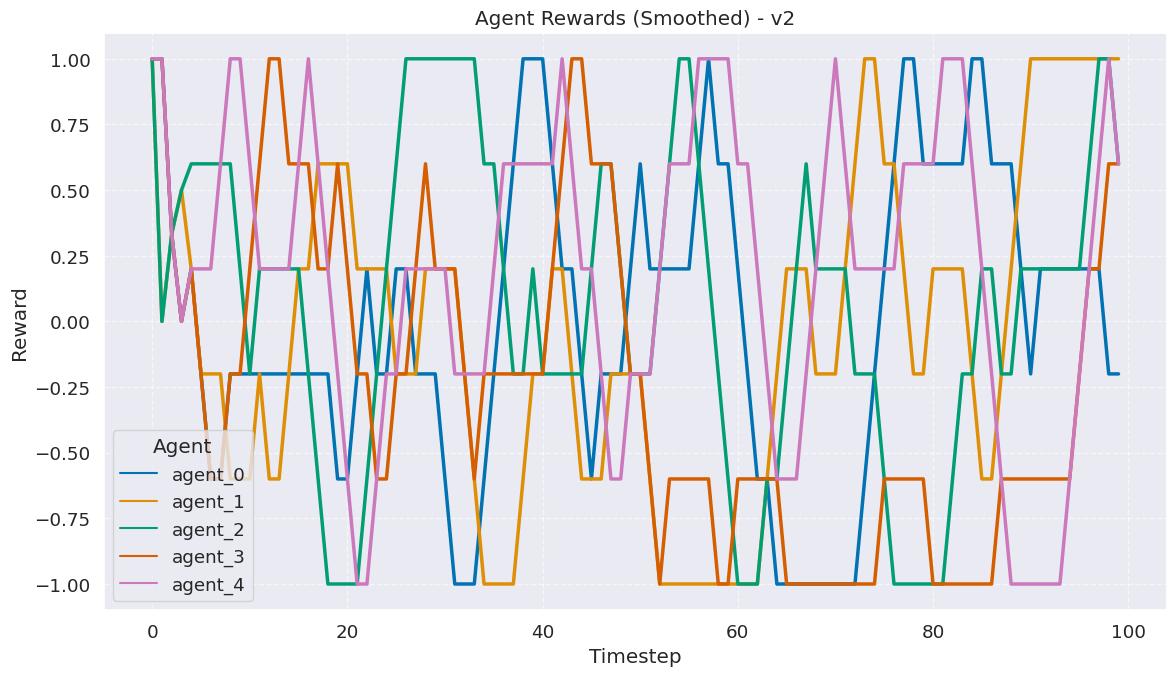

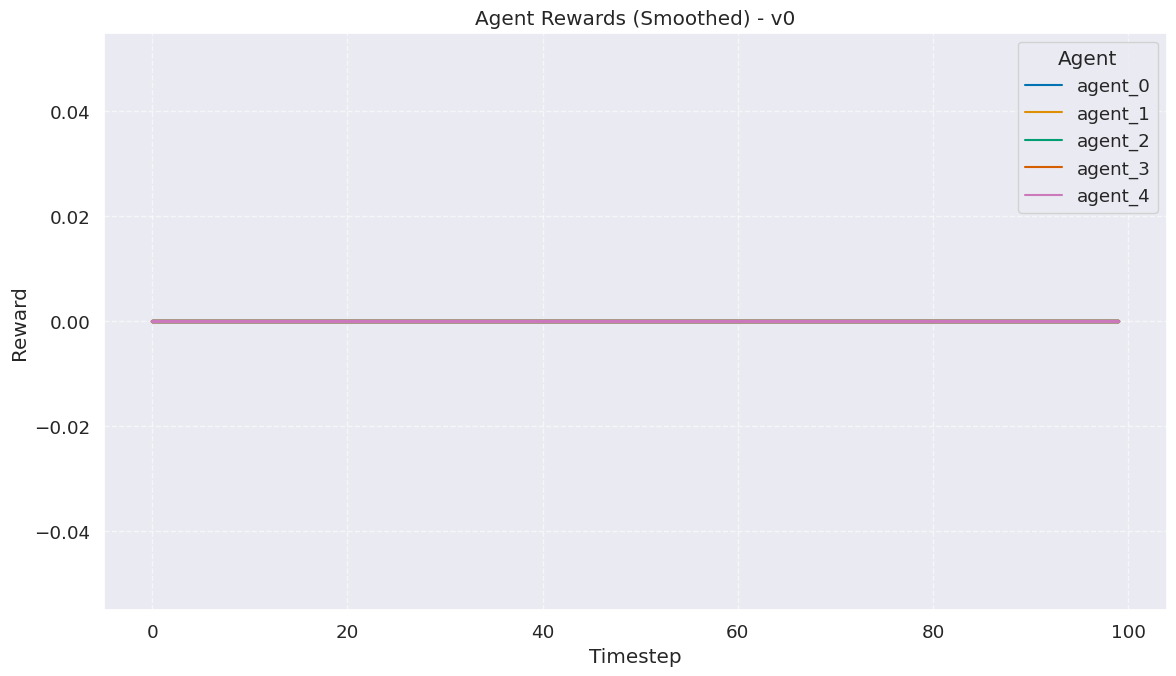

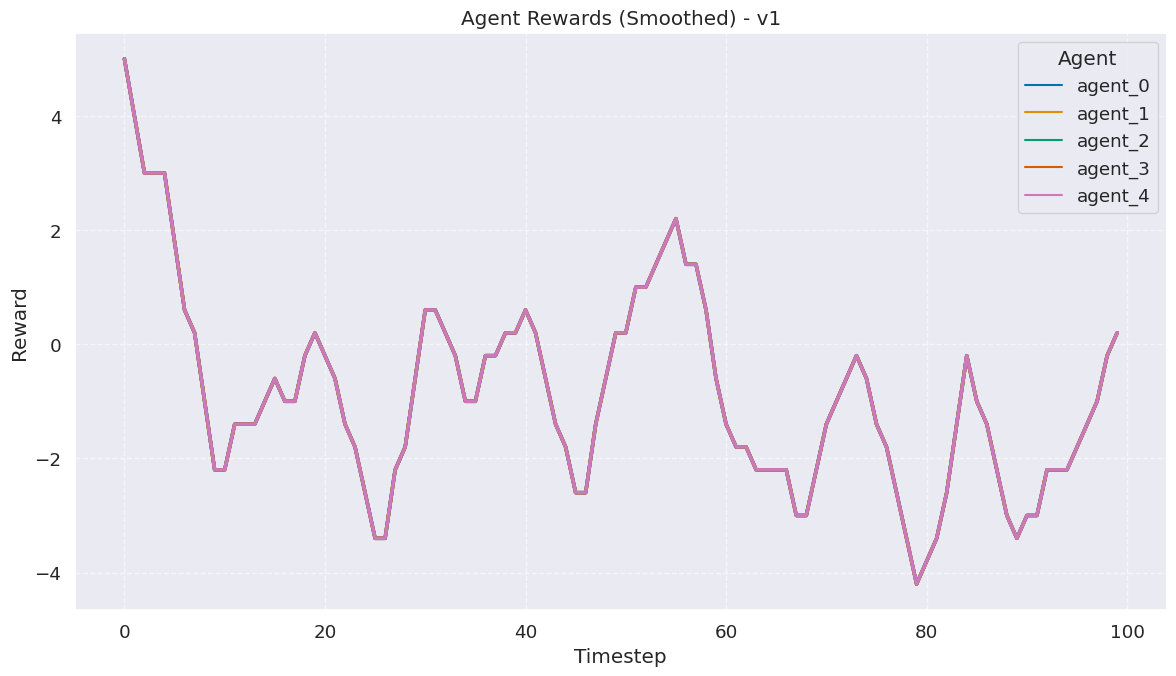

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set_theme(style="darkgrid", palette="colorblind", font_scale=1.2)

window_size = 5  # Rolling window size

for name in train_rewards:
    agents = train_rewards[name]

    # Apply rolling window smoothing
    smoothed = agents.rolling(window=window_size, min_periods=1).mean()

    # Prepare for plotting
    df_long = smoothed.reset_index().melt(
        id_vars='index', var_name='Agent', value_name='Value'
    )

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df_long, x='index', y='Value', hue='Agent', linewidth=2.5)

    plt.xlabel('Step')
    plt.ylabel('Reward')
    plt.title(f'Agent Rewards (Smoothed) - {name}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
